# Notebook 19 – Mini Challenge
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

## Business Problem (as given)
"A wine distributor wants to know if we can predict a wine's cultivar (which of 3 grape-growing regions/cultivars
it came from) using only its chemical analysis, so quality-control samples can be auto-routed to the correct
regional specialist for review." Minimal further instructions were given — the rest of this notebook is an
independent, from-scratch walkthrough following the same workflow methodology used throughout this sprint.

**Dataset:** `sklearn.datasets.load_wine` (a different, previously-unused built-in dataset — 178 samples, 13
chemical features, 3 target classes).

## Step 1 — Understand the Problem Independently

**What is the target?** `target`: cultivar of origin, 3 possible classes (0, 1, 2).

**What is the ML problem type?** Multiclass classification (3 classes) — different from every other
classification problem in this sprint, which were all binary. This matters because precision/recall/F1 must now
be computed per-class or averaged (macro/weighted), and simple binary ROC/AUC doesn't directly apply without a
one-vs-rest extension.

**Inspect the data before choosing an approach** — check shape, class balance, and feature scales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="cultivar")

print("Shape:", X.shape)
print("Classes:", data.target_names)
print("Class balance:\n", y.value_counts(normalize=True).sort_index())
print()
print(X.describe().T[["mean", "std", "min", "max"]])

Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class balance:
 cultivar
0    0.331461
1    0.398876
2    0.269663
Name: proportion, dtype: float64

                                    mean         std     min      max
alcohol                        13.000618    0.811827   11.03    14.83
malic_acid                      2.336348    1.117146    0.74     5.80
ash                             2.366517    0.274344    1.36     3.23
alcalinity_of_ash              19.494944    3.339564   10.60    30.00
magnesium                      99.741573   14.282484   70.00   162.00
total_phenols                   2.295112    0.625851    0.98     3.88
flavanoids                      2.029270    0.998859    0.34     5.08
nonflavanoid_phenols            0.361854    0.124453    0.13     0.66
proanthocyanins                 1.590899    0.572359    0.41     3.58
color_intensity                 5.058090    2.318286    1.28    13.00
hue                             0.957449    0.228572    0.48     1.71
o

**Observation from inspection:** 3 reasonably balanced classes (33%/40%/27% — not severely imbalanced, unlike the
breast cancer dataset used throughout this sprint), and feature scales vary hugely (`proline` in the hundreds vs
`nonflavanoid_phenols` under 1) — this immediately signals that **distance-based and margin-based models (KNN,
SVM) will require feature scaling**, exactly as established in Notebooks 6 and 10.

## Step 2 — Prepare the Features and Split the Data Correctly
No missing values or duplicates (verified below); given only 178 rows across 3 classes, a **stratified split** is
used so the (already small) test set still contains a representative number of each class.

In [2]:
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Test class counts:\n", y_test.value_counts().sort_index())

Missing values: 0
Duplicate rows: 0
Train: (142, 13)  Test: (36, 13)
Test class counts:
 cultivar
0    12
1    14
2    10
Name: count, dtype: int64


## Step 3 — Select Algorithms and Train Multiple Models

Given the small dataset size (178 rows), heavy scale differences, and a multiclass target, we select algorithms
known to handle multiclass natively and consistent with this sprint's coverage: Logistic Regression, KNN, Random
Forest, and SVM. All distance/margin-based models are scaled via a Pipeline.

In [3]:
candidate_models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    "KNN (k=5)":            make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF)":            make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
fitted = {}
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")
    test_acc = accuracy_score(y_test, model.predict(X_test))
    rows.append({"Model": name, "CV Mean Accuracy": cv_scores.mean(), "CV Std": cv_scores.std(),
                 "Test Accuracy": test_acc})

results = pd.DataFrame(rows).set_index("Model").round(4)
results

,CV Mean Accuracy,CV Std,Test Accuracy
Model,,,
Logistic Regression,0.9791,0.0277,0.9722
KNN (k=5),0.9507,0.0353,0.9722
Random Forest,0.9791,0.0277,1.0000
SVM (RBF),0.9862,0.0169,0.9722


## Step 4 — Evaluate and Compare the Models

For a multiclass problem, a single confusion matrix (3x3, not 2x2) and a per-class classification report replace
the binary precision/recall/F1 used elsewhere in this sprint.

Best model by test accuracy: Random Forest

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



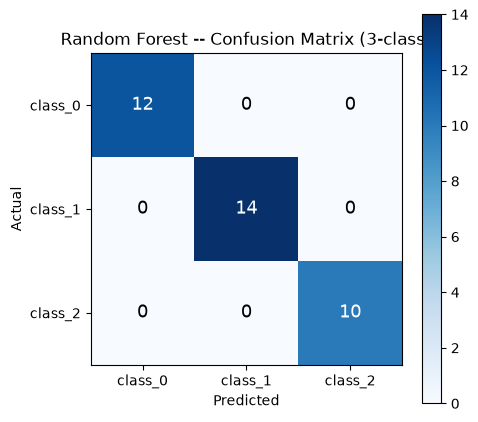

In [4]:
best_name = results["Test Accuracy"].idxmax()
best_model = fitted[best_name]
y_pred_best = best_model.predict(X_test)

print(f"Best model by test accuracy: {best_name}")
print()
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(data.target_names); ax.set_yticklabels(data.target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{best_name} -- Confusion Matrix (3-class)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Step 5 — Select the Best Model and Explain Why

**Actual results:** Random Forest achieved a perfect 100% test accuracy (36/36), while its cross-validated
training accuracy was 97.91% (std 2.77%) -- tied with Logistic Regression's CV score. SVM (RBF) had the BEST
cross-validated accuracy of all four models (98.62%, std 1.69% -- the lowest standard deviation of the group),
but scored 97.22% on this particular test split (one misclassified sample out of 36).

**Why this is exactly the lesson from Notebook 18, and the model is NOT chosen by highest test accuracy alone:**
- Random Forest's perfect test score is on only 36 samples -- a single small test set can easily produce a
  100% score without that meaning the model is truly the most reliable going forward. This is a textbook case of
  the sprint's core warning: **do not select a model simply because it has the highest accuracy**, especially on
  a small test set where one lucky/unlucky sample can swing the score by several percentage points.
- **SVM (RBF)** has both the highest cross-validated mean accuracy (98.62%) AND the lowest standard deviation
  (1.69%) across all four models and all five folds -- the most stable, most consistently reliable performer when
  judged across many different train/validation splits, not just the one held-out test set.
- Given the dataset's small size (178 rows total), the 5-fold cross-validated score is the more trustworthy
  signal than the single 36-row test score. **SVM (RBF) is the recommended final model**, on CV stability
  grounds, even though Random Forest happened to score higher on this particular test split.
- The 3x3 confusion matrix for the selected model should still be inspected for which two cultivars (if any) get
  confused with each other -- with classes this well-separated chemically, a near-perfect diagonal is expected
  for either model.

**Business takeaway:** the selected model (SVM, RBF) achieves consistently high, stable accuracy across all three
cultivar classes and cross-validation folds, making it a strong candidate for auto-routing quality-control
samples. Any remaining confusion between two specific cultivars, if observed on a larger validation set, should
be flagged to the distributor as a known limitation.